# OFFLINE AUGMENTATION

## LIBRARIES

In [22]:
#uncomment this installation in case your environment doesn't have keras cv
#!pip install keras-cv

In [23]:
seed = 42

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split 
import tensorflow as tf
from tensorflow import keras as tfk
import matplotlib.pyplot as plt
from skimage.transform import rotate
from scipy.ndimage import shift
import random
import scipy.ndimage
from skimage import exposure
import cv2
from collections import Counter


# Input data files are available in the read-only "../input/" directory
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/blood-cells-wout-shrek/preprocessed_training_set.npz


## Load of the cleaned Dataset

In [24]:
data = np.load('/kaggle/input/blood-cells-wout-shrek/preprocessed_training_set.npz')
images = data['images']
labels = data['labels']

## Split of the dataset in Train set and Test set

In [25]:
#splitting function
images_train, images_test, labels_train, labels_test = train_test_split(
    images,
    labels,
    test_size = 0.2,
    random_state=seed,
    stratify=labels
)

#converting the labels in one-hot-encoding
labels_train = tfk.utils.to_categorical(labels_train)
labels_test = tfk.utils.to_categorical(labels_test)

#saving of the test set (will not be augmented)
np.savez('new_validation_set.npz', images=images_test, labels=labels_test)

## Display of the original images for Data Inspection

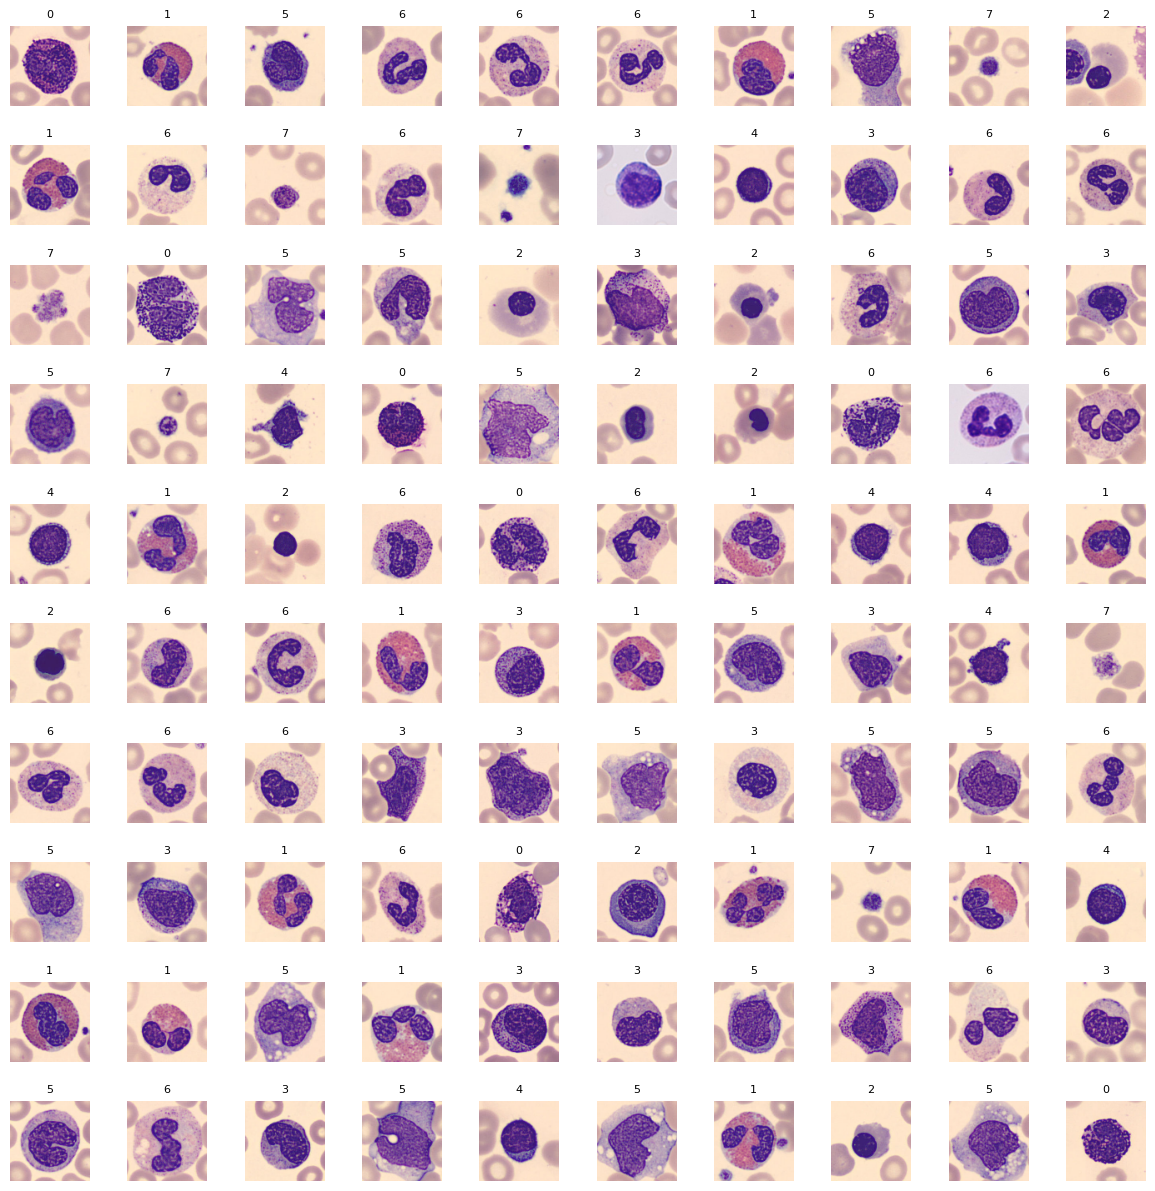

In [43]:
# Load the data
data1 = np.load('/kaggle/working/new_validation_set.npz')
images1 = data1['images']
labels1 = data1['labels']

# Select 100 random indices
random_indices = np.random.choice(len(images1), size=100, replace=False)
random_images = images1[random_indices]
random_labels = labels1[random_indices]

# Set up a 10x10 grid for displaying the images
fig, axes = plt.subplots(10, 10, figsize=(15, 15))
fig.subplots_adjust(hspace=0.5, wspace=0.1) 

# Plot each image in the grid
for i, ax in enumerate(axes.flat):
    ax.imshow(random_images[i])  
    ax.set_title(str(np.argmax(random_labels[i])), fontsize=8)  
    ax.axis('off')

plt.show()

## Class Distribution

Original class distribution: {0: 682, 1: 1745, 2: 868, 3: 1621, 4: 679, 5: 794, 6: 1864, 7: 1314}
Smallest Class has:  679
Biggest Class has:  1864
Unique Labels:  [0 1 2 3 4 5 6 7] 



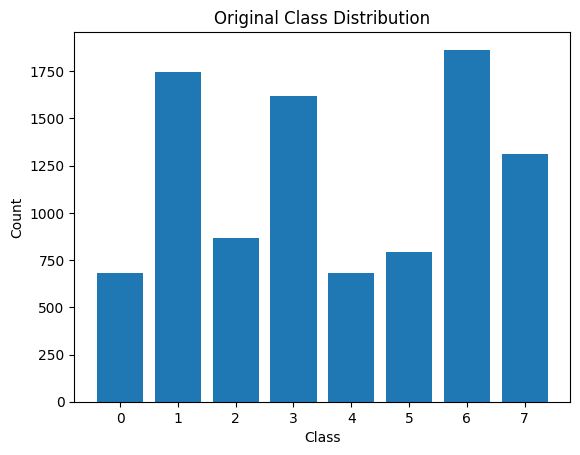

In [44]:
# Load the data
images = images_train
labels = labels_train

# Get class distribution using np.unique
integer_labels = np.argmax(labels, axis=1)
unique_labels, counts = np.unique(integer_labels, return_counts=True)
class_counts = dict(zip(unique_labels, counts))
print("Original class distribution:", class_counts)

min_class= min(class_counts.values())
max_class= max(class_counts.values())
print("Smallest Class has: ", min_class)
print("Biggest Class has: ", max_class)

unique_labels, counts = np.unique(np.argmax(labels, axis=1), return_counts=True)


print("Unique Labels: ", unique_labels, "\n")

# Plot class distribution
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Original Class Distribution')
plt.show()

## Managing Class Imbalance

### Undersamplin Function (not actually used)

In [28]:
#Undersample classes that exceed the target size while leaving smaller classes unchanged.
def undersample_dataset_to_target(images, labels, target_size):
    
    # Convert one-hot encoded labels to class indices
    class_indices = np.argmax(labels, axis=1)
    
    # Count samples in each class
    class_counts = Counter(class_indices)
    
    # Find indices for each class
    class_indices_list = [np.where(class_indices == i)[0] for i in range(labels.shape[1])]
    
    # Select samples for each class
    balanced_indices = []
    for class_idx in class_indices_list:
        if len(class_idx) > target_size:
            # If class is larger than target, randomly select target_size samples
            selected_indices = np.random.choice(class_idx, target_size, replace=False)
        else:
            # If class is smaller than target, keep all samples
            selected_indices = class_idx
        balanced_indices.extend(selected_indices)
    
    # Convert to numpy array and shuffle
    balanced_indices = np.array(balanced_indices)
    np.random.shuffle(balanced_indices)
    
    # Select the balanced dataset
    balanced_images = images[balanced_indices]
    balanced_labels = labels[balanced_indices]
    
    return balanced_images, balanced_labels


## AUGMENTATION

In [29]:
#Function used to generate a statistically dispersed uniform random value 
#for the factor used in augmentation functions.

def statistically_dispersed_uniform(lower_bound=0.5, upper_bound=2.0, mean=1.0, std=0.5):
    
    # Use 3 standard deviations to create a statistically meaningful spread
    multiplier = 3
    
    # Calculate initial lower and upper bounds based on mean and standard deviation
    stat_lower = max(lower_bound, mean - (multiplier * std))
    stat_upper = min(upper_bound, mean + (multiplier * std))
    
    # Ensure the bounds are within the original specified range
    stat_lower = max(lower_bound, stat_lower)
    stat_upper = min(upper_bound, stat_upper)
    
    # Generate value using uniform distribution within calculated bounds
    return np.random.uniform(stat_lower, stat_upper)

## Augmentation Functions

In [30]:
# Define augmentation functions

def rotate_image(image, angle):
    return scipy.ndimage.rotate(image, angle, mode='reflect')

def shift_image(image, dx, dy):
    return shift(image, [dx, dy, 0], mode='wrap')

def flip_image(image, axis):
    return np.flip(image, axis=axis)

def mixup(image1, label1, image2, label2, alpha=6):
    
    # Generate the mixup coefficient using a beta distribution
    lambda_val = np.random.beta(8.3, 4.0)
    
    # Perform the mixup operation with intermediate float32 precision
    mixed_image = (lambda_val * image1.astype(np.float32) + (1 - lambda_val) * image2.astype(np.float32))
    
    # Clip to ensure values stay within 0-255 range and convert back to uint8
    mixed_image = np.clip(mixed_image, 0, 255).astype(np.uint8)
    
    # Mix the labels as usual
    mixed_label = lambda_val * label1 + (1 - lambda_val) * label2
    
    return mixed_image,mixed_label

#not actually used
def cutmix(image1, label1, image2, label2, alpha=1.0):
    
    lambda_val = np.random.beta(8, 2)
    h, w, _ = image1.shape
    
    cut_rat = np.sqrt(1 - lambda_val)
    cut_w = int(w * cut_rat)
    cut_h = int(h * cut_rat)
    
    # Choose random position for the CutMix box
    cx = np.random.randint(w)
    cy = np.random.randint(h)
    
    bbx1 = np.clip(cx - cut_w // 2, 0, w)
    bby1 = np.clip(cy - cut_h // 2, 0, h)
    bbx2 = np.clip(cx + cut_w // 2, 0, w)
    bby2 = np.clip(cy + cut_h // 2, 0, h)
    
    # Apply CutMix
    mixed_image = np.copy(image1)
    mixed_image[bby1:bby2, bbx1:bbx2, :] = image2[bby1:bby2, bbx1:bbx2, :]
    
    # Adjust lambda to exactly match the proportion of the area of the cut region
    lambda_val = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (h * w))
    mixed_label = lambda_val * label1 + (1 - lambda_val) * label2
    return mixed_image, mixed_label


def adjust_brightness(image, beta):
    return cv2.convertScaleAbs(image, alpha=1, beta=beta)

def adjust_contrast(image, alpha):
    return cv2.convertScaleAbs(image, alpha=alpha, beta=0)

def adjust_saturation(image, factor):
    hsv_image = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    hsv_image[:, :, 1] = cv2.convertScaleAbs(hsv_image[:, :, 1], alpha=factor)
    return cv2.cvtColor(hsv_image, cv2.COLOR_HSV2RGB)

def gaussian_blur(image, kernel_size=5):
    return cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)

def histogram_equalization(image):
    if len(image.shape) == 3 and image.shape[2] == 3: 
        hsv_image = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
        hsv_image[:, :, 2] = cv2.equalizeHist(hsv_image[:, :, 2])
        return cv2.cvtColor(hsv_image, cv2.COLOR_HSV2RGB)
    else:
        return cv2.equalizeHist(image)

def rgb_jitter(image, jitter_factor=0.05):
    jittered_image = image.copy().astype(np.float32)
    for channel in range(3):
        jitter = np.random.uniform(-jitter_factor, jitter_factor)
        jittered_image[:, :, channel] = np.clip(jittered_image[:, :, channel] + jitter * 255, 0, 255)
    return jittered_image.astype(np.uint8)

def adjust_zoom(image, factor):
    h, w = image.shape[:2]
    new_h = int(h * factor)
    new_w = int(w * factor)
    
    if factor > 1:
        # Resize to larger dimensions
        zoomed = cv2.resize(image, (new_w, new_h))
        # Calculate crop coordinates to maintain original size
        start_y = (new_h - h) // 2
        start_x = (new_w - w) // 2
        zoomed = zoomed[start_y:start_y+h, start_x:start_x+w]
    else:
        # Calculate padding
        pad_h = (h - new_h) // 2
        pad_w = (w - new_w) // 2
        # Resize to smaller dimensions
        zoomed = cv2.resize(image, (new_w, new_h))
        # Pad to maintain original size
        zoomed = cv2.copyMakeBorder(
            zoomed, 
            pad_h, h-new_h-pad_h,
            pad_w, w-new_w-pad_w,
            cv2.BORDER_CONSTANT,
            value=[0, 0, 0]
        )
    
    return zoomed


def channel_shuffle(image, shuffle_prob=0.5):
    shuffled_image = image.copy()
    
    if np.random.random() < shuffle_prob:
        # Randomly permute channel indices
        channel_order = np.random.permutation(3)
        shuffled_image = shuffled_image[:, :, channel_order]
    
    return shuffled_image

def apply_gridmask(image, min_grid_size=20, max_grid_size=50, angle=0, ratio=0.5):
  
    h, w, c = image.shape
    
    # Generate a fixed grid size for consistent block sizes
    grid_size = np.random.randint(min_grid_size, max_grid_size + 1)
    
    # Create a mask with the same size as the input image
    mask = np.ones((h, w), dtype=np.uint8)
    
    # Randomly generate starting points with additional randomness
    start_x = np.random.randint(-grid_size, grid_size)
    start_y = np.random.randint(-grid_size, grid_size)
    
    # Apply the grid mask pattern
    for y in range(start_y, h, grid_size):
        for x in range(start_x, w, grid_size):
            x_end = min(w, x + int(grid_size * ratio))
            y_end = min(h, y + int(grid_size * ratio))
            mask[y:y_end, x:x_end] = 0  # Mask the ratio portion of the grid
    
    # Rotate the mask if an angle is specified
    if angle != 0:
        center = (w // 2, h // 2)
        rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
        mask = cv2.warpAffine(mask, rotation_matrix, (w, h), flags=cv2.INTER_NEAREST)
    
    # Apply the mask to the image
    result = cv2.bitwise_and(image, image, mask=mask)
    
    return result

def apply_cutout(image, num_holes=1, hole_size=(30, 30)):
    h, w, c = image.shape
    result = image.copy()

    for _ in range(num_holes):
        y = np.random.randint(0, h - hole_size[0])
        x = np.random.randint(0, w - hole_size[1])
        y_end = y + hole_size[0]
        x_end = x + hole_size[1]
        result[y:y_end, x:x_end] = 0  # Fill the cutout area with black

    return result

def apply_random_shear(image):
    rows, cols = image.shape[:2]
    shear_factor = np.random.uniform(-0.5, 0.5)
    
    # Create affine matrix for shear
    M = np.float32([
        [1, shear_factor, 0],
        [0, 1, 0]
    ])
    
    # Calculate new width to prevent cropping
    new_width = int(cols + abs(shear_factor * rows))
    
    # Adjust transformation matrix to center the image
    M[0, 2] = abs(shear_factor * rows) if shear_factor < 0 else 0
    
    # Apply affine transformation
    sheared_img = cv2.warpAffine(
        image, 
        M, 
        (new_width, rows),
        borderMode=cv2.BORDER_REPLICATE
    )
    
    # Crop back to original size if needed
    if new_width > cols:
        start = (new_width - cols) // 2
        sheared_img = sheared_img[:, start:start+cols]
    
    return sheared_img
    
def apply_random_fog(image, fog_intensity=0.5, fog_color=(255, 255, 255)):
    h, w, c = image.shape
    noise = np.random.normal(loc=0.5, scale=0.5, size=(h, w, 1)).clip(0, 1)

    # Scale noise to fog intensity and color, and ensure it's uint8
    fog_layer = (noise * 255 * fog_intensity).astype(np.uint8)
    fog_layer = cv2.merge([fog_layer * (fog_color[i] / 255) for i in range(3)])
    fog_layer = fog_layer.astype(np.uint8)

    # Ensure input image is also uint8
    if image.dtype != np.uint8:
        image = image.astype(np.uint8)

    # Blend the fog layer with the image
    foggy_image = cv2.addWeighted(image, 1 - fog_intensity, fog_layer, fog_intensity, 0)

    return foggy_image



### Augmentation parameters


In [31]:
angles = [90, -90, 180]  # Rotation angles
shifts = [(20, 20), (-20, -20), (20, -20), (-20, 20)]  # Shift in x, y
flip_axes = [0, 1]  # Horizontal and vertical flip


# Target count for each class (uniform case)
target_count = 2000
# Target count for each class (not uniform case)
target_array = [4700,5300,5000,5200,4900,5100,5400,5200]

# Initialize lists for augmented images and labels
augmented_images = []
augmented_labels = []

# Initialize a dictionary to keep track of augmented counts per class
augmented_counts = {label: 0 for label in unique_labels}

# Create a one-hot encoded vector of the unique classes
unique_classes = np.where(np.sum(labels, axis=0) > 0)[0]
label_classes = np.eye(len(unique_classes))

### Application of the Augmentations

In [32]:
# Loop through each class and apply augmentations
for class_label in label_classes:
    
    # Select all images of the current class
    class_images = images[np.all(labels == class_label, axis=1)]
    class_size = class_counts[np.argmax(class_label)]
    
    # Add original images of the class to augmented data
    augmented_images.extend(class_images)
    augmented_labels.extend([class_label] * len(class_images))  # Append one-hot encoded labels
    
    # Update the count of augmented images for this class
    augmented_counts[np.argmax(class_label)] += class_size

    #target_count=min(class_size+min_class, max_class+300)
    target_count=target_array[np.argmax(class_label)]
    print(target_count)
    # Apply augmentations to reach the target count for this class
    while augmented_counts[np.argmax(class_label)] < target_count:
        # Select a random image from the class to augment
        img = random.choice(class_images)
        
        # Apply a random augmentation
        aug_type = random.choice(['shift','mixup', 'saturation', 'blur', 'rgb_jitter','zoom','shuffle'])
        
        if aug_type == 'rotate':
            img_aug = rotate_image(img, angle=random.choice(angles))
            label_aug = class_label
            
        elif aug_type == 'shift':
            dx, dy = random.choice(shifts)
            img_aug = shift_image(img, dx, dy)
            label_aug = class_label
            
        elif aug_type == 'flip':
            axis = random.choice(flip_axes)
            img_aug = flip_image(img, axis=axis)
            label_aug = class_label
            
        elif aug_type == 'mixup':
            # For MixUp, select a random second image and mix them
            filtered_indices = np.where(labels != class_label)[0]
            random_index = np.random.choice(filtered_indices)
            mix_img = images[random_index]
            mix_label = labels[random_index]
            img_aug, label_aug = mixup(img, class_label, mix_img, mix_label)
            
        elif aug_type == 'cutmix':
            # For CutMix, select a random second image and cut-mix them
            filtered_indices = np.where(labels != class_label)[0]
            random_index = np.random.choice(filtered_indices)
            cut_img = images[random_index]
            cut_label = labels[random_index]
            img_aug, label_aug = cutmix(img, class_label, cut_img, cut_label)
            
        elif aug_type == 'brightness':
            # Adjust brightness with a random factor between 0.5 and 2.0
            factor = statistically_dispersed_uniform(
                    lower_bound=0.5, 
                    upper_bound=1.5, 
                    mean=1.0, 
                    std=0.5
            )
            img_aug = adjust_brightness(img, factor)
            label_aug = class_label
            
        elif aug_type == 'contrast':
            # Adjust contrast with a random factor between 0.5 and 2.0
            factor = statistically_dispersed_uniform(
                    lower_bound=0.5, 
                    upper_bound=1.6, 
                    mean=1.0, 
                    std=0.5
            )
            
            img_aug = adjust_contrast(img, factor)
            label_aug = class_label

        elif aug_type == 'saturation':
            # Adjust saturation with a random factor between 0.5 and 2.0
            factor = statistically_dispersed_uniform(
                    lower_bound=0.5, 
                    upper_bound=2.5, 
                    mean=1.0, 
                    std=1.0
            )
            img_aug = adjust_saturation(img, factor)
            label_aug = class_label

        elif aug_type == 'blur':
            # Apply Gaussian blur with a random kernel size (odd number between 3 and 7)
            kernel_size = random.choice([3, 5, 7])
            img_aug = gaussian_blur(img, kernel_size=kernel_size)
            label_aug = class_label

        elif aug_type == 'histogram_equalization':
            # Apply histogram equalization
            img_aug = histogram_equalization(img)
            label_aug = class_label

        elif aug_type == 'rgb_jitter':
            # Apply RGB channel jittering with a random factor between 0.01 and 0.1
            jitter_factor = random.uniform(0.5,2.0)
            img_aug = rgb_jitter(img, 0.5)
            label_aug = class_label
            
        elif aug_type == 'zoom':
            zoom_factor = random.uniform(1.2,1.3)
            img_aug = adjust_zoom(img,zoom_factor)
            label_aug = class_label
            
        elif aug_type == 'shuffle':
            img_aug = channel_shuffle(img,1.0)
            label_aug = class_label
   
        img2 = img_aug
        class_label2 = label_aug

        for i in range(8):
        
            aug_type = random.choice(['contrast', 'saturation','rgb_jitter','shuffle','shear','shear'])
    
            if aug_type == 'rgb_jitter':
                # Apply RGB channel jittering with a random factor between 0.01 and 0.1
                jitter_factor = random.uniform(0.5,2.0)
                img2 = rgb_jitter(img2, 0.3)
                
            elif aug_type == 'shuffle':
                img2 = channel_shuffle(img2,1.0)
                
            elif aug_type == 'saturation':
                # Adjust saturation with a random factor between 0.5 and 2.0
                factor = statistically_dispersed_uniform(
                        lower_bound=0.5, 
                        upper_bound=1.6, 
                        mean=1.0, 
                        std=1.0
                )
                img2 = adjust_saturation(img2, factor)
            
            elif aug_type == 'contrast':
                # Adjust contrast with a random factor between 0.5 and 2.0
                factor = statistically_dispersed_uniform(
                        lower_bound=0.5, 
                        upper_bound=1.6, 
                        mean=1.0, 
                        std=0.5
                )
                
                img2 = adjust_contrast(img2, factor)
                
            elif aug_type == 'shear':
                img2 = apply_random_shear(img2)

                
             
        label_aug = class_label2
        img_aug = img2
        
        img3 = img_aug
        class_label3 = label_aug 
        
        aug_type = random.choice(['gridmask', 'cutout','shear','fog','blur','saturation','shift'])
        
        if aug_type == 'gridmask':
            # Apply RGB channel jittering with a random factor between 0.01 and 0.1
            img_aug = apply_gridmask(img3)
            label_aug = class_label3
        
        elif aug_type == 'cutout':
            img_aug = apply_cutout(img3)
            label_aug = class_label3
        
        elif aug_type == 'shear':
            img_aug = apply_random_shear(img3)
            label_aug = class_label3
        
        elif aug_type == 'fog':
            img_aug = apply_random_fog(img3)
            label_aug = class_label3
        
        elif aug_type == 'blur':
            # Apply Gaussian blur with a random kernel size (odd number between 3 and 7)
            kernel_size = random.choice([3, 5, 7])
            img_aug = gaussian_blur(img, kernel_size=kernel_size)
            label_aug = class_label
        
        elif aug_type == 'saturation':
            # Adjust saturation with a random factor between 0.5 and 2.0
            factor = statistically_dispersed_uniform(
                    lower_bound=0.5, 
                    upper_bound=2.5, 
                    mean=1.0, 
                    std=1.0
            )
            img_aug = adjust_saturation(img2, factor)
            label_aug = class_label2

        elif aug_type == 'shift':
            dx, dy = random.choice(shifts)
            img_aug = shift_image(img3, dx, dy)
            label_aug = class_label3
        
        elif aug_type == 'null':
            img_aug = img3
            label_aug = class_label3
        
        

        # Add the augmented image and its label to the list
        
        augmented_images.append(img_aug)
        augmented_labels.append(label_aug)

        # Increment the augmented count for the current class
        augmented_counts[np.argmax(label_aug)] += 1
        

    
augmented_images_copy = augmented_images
augmented_labels_copy = augmented_labels

        
# Convert lists to numpy arrays
augmented_images = np.array(augmented_images)
augmented_images = augmented_images.astype(np.uint8)
augmented_labels = np.array(augmented_labels)





# Save augmented images and labels as .npz
np.savez('/kaggle/working/augmented_training_set_2.npz', images=augmented_images, labels=augmented_labels)
        


4700
5300
5000
5200
4900
5100
5400
5200


### New Class distribution after the augmentation process

Augmented class distribution:  {0: 4725, 1: 5366, 2: 5029, 3: 5250, 4: 4912, 5: 5109, 6: 5410, 7: 5200}


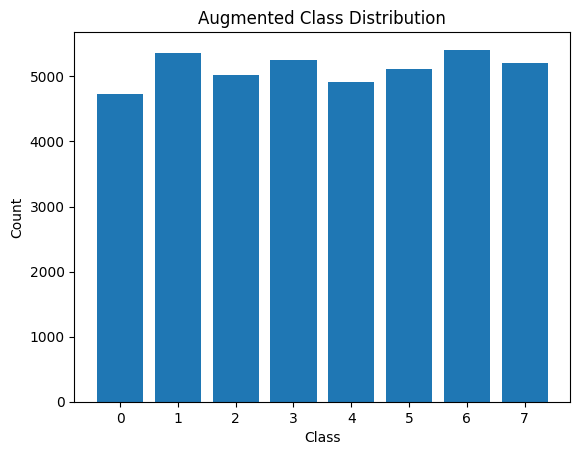

In [33]:
# Check the new class distribution
for aug in range(len(augmented_labels_copy)):
    augmented_labels_copy[aug] = np.argmax(augmented_labels_copy[aug])


unique_augmented_labels, augmented_counts = np.unique(augmented_labels_copy, return_counts=True)
new_class_counts = dict(zip(unique_augmented_labels, augmented_counts))
print("Augmented class distribution: ", new_class_counts,"\n")        


# Optional: plot new distribution
plt.bar(new_class_counts.keys(), new_class_counts.values())
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Augmented Class Distribution')
plt.show()


### Display of 100 random images after the Augmentation process

Shape of augmented_images: (41001, 96, 96, 3)
Shape of augmented_labels: (41001, 8)


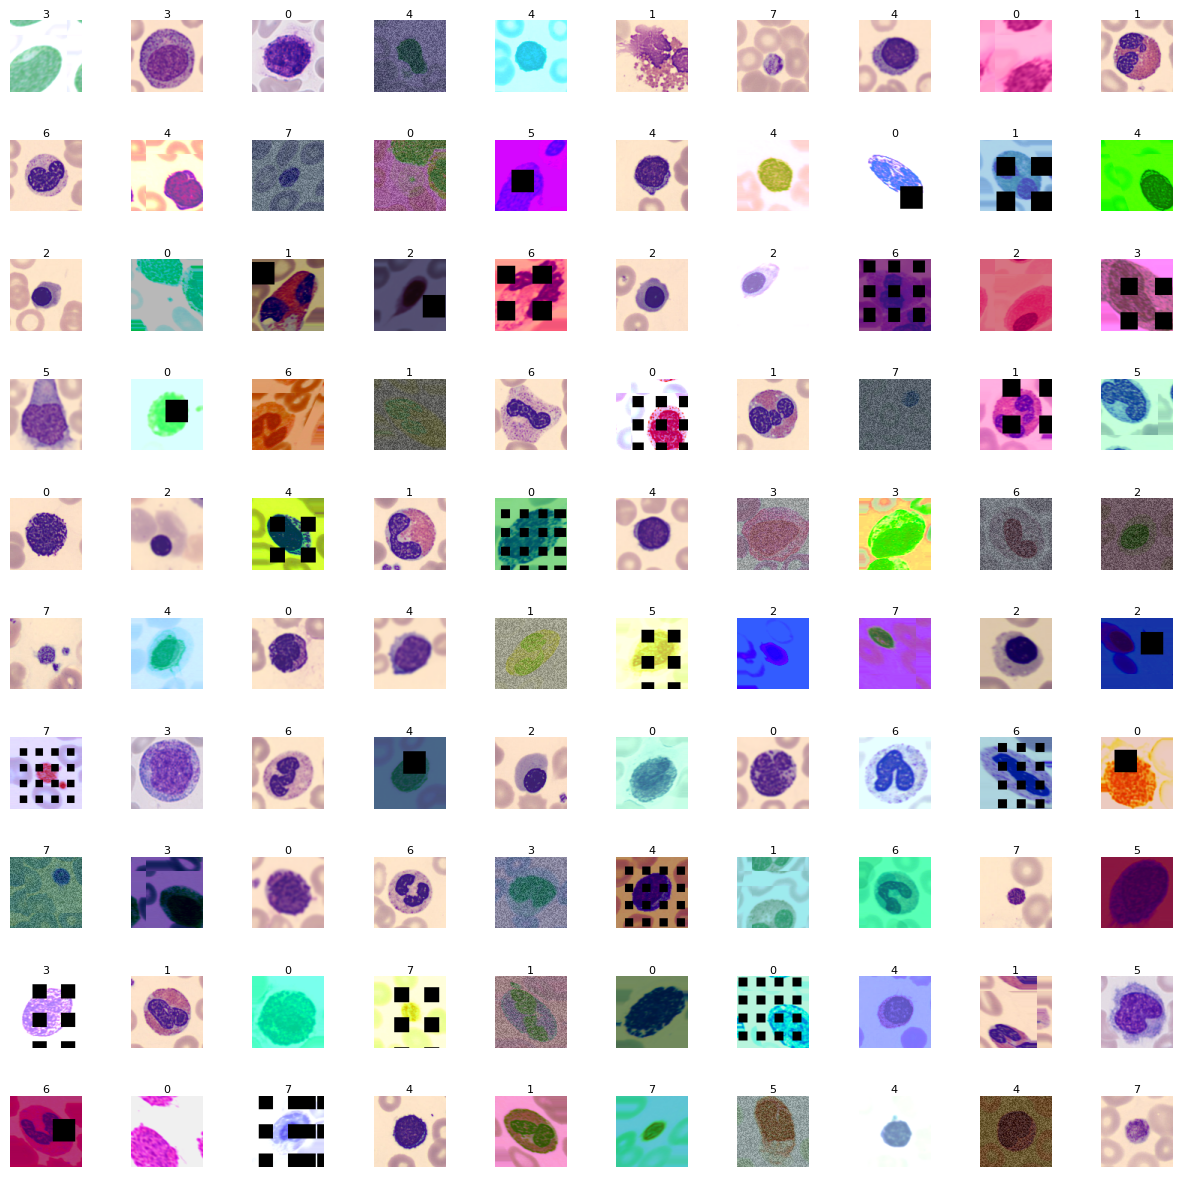

In [49]:
data = np.load('/kaggle/working/augmented_training_set_2.npz')
augmented_images = data['images']
labels = data['labels']

# Select 100 random indices
random_indices = np.random.choice(len(augmented_images), size=100, replace=False)
random_images = augmented_images[random_indices]
random_labels = labels[random_indices]

# Print shapes for verification
print("Shape of augmented_images:", augmented_images.shape)
print("Shape of augmented_labels:", labels.shape)

# Set up a 10x10 grid for displaying the images
fig, axes = plt.subplots(10, 10, figsize=(15, 15))
fig.subplots_adjust(hspace=0.5, wspace=0.7)  # Increased hspace to make room for labels

# Plot each image in the grid
for i, ax in enumerate(axes.flat):
    # Display the image
    ax.imshow(random_images[i], cmap='gray')  # Assuming grayscale; remove cmap if RGB
    
    # Add the label as a title above the image
    # Note that in our augmentation we apply mixUp which makes some label SOFT
    # but here in order to make the plot more readable we applied argmax on the display of the labels
    # just for displaying purpouse
    ax.set_title(str(np.argmax(random_labels[i])), fontsize=8, pad=2)
    
    # Remove axes
    ax.axis('off')

plt.show()
